# Task 03 - Classificação: nível de visibilidade digital

Este notebook cria um classificador exploratório para prever o nível de visibilidade (`baixo`, `medio` ou `alto`) no dataset real **contempArt**.

Objetivo para o FlowCarreiras:

> Investigar quais sinais disponíveis distinguem níveis de visibilidade e demonstrar por que esse resultado não deve ser usado como ranking de mérito artístico.

`follower_count`, curtidas, comentários, taxa de engajamento e variáveis derivadas deles são excluídos das features para evitar vazamento de dados.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_fscore_support,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

DATA_PATH = Path("../data/processed/contempart_artists_enriquecido.csv")
df = pd.read_csv(DATA_PATH)
print(f"Registros carregados: {len(df)}")


Registros carregados: 441


## 1. Features, alvo e prevenção de vazamento

O alvo foi derivado dos percentis de seguidores. Por isso, nenhuma variável baseada em seguidores ou interação proporcional a seguidores pode entrar como preditora.

Features utilizadas:

- volume disponível: posts e imagens;
- comportamento de conta: seguindo, conta comercial e conta privada;
- presença de website;
- características médias das imagens;
- escola, região, gênero e classe de professor, quando preenchidos.

Valores ausentes são imputados dentro do pipeline, utilizando mediana para números e categoria mais frequente para categorias.


In [2]:
alvo = "nivel_visibilidade"
numericas = [
    "following_count", "posts_count", "img_count",
    "avg_file_size", "avg_width", "avg_height", "avg_aspect_ratio",
]
categoricas = [
    "possui_website", "is_business", "is_private",
    "school", "region", "gender", "professor_class",
]
features = numericas + categoricas

base = df.loc[df[alvo].notna(), features + [alvo]].copy()
print(f"Registros válidos para classificação: {len(base)}")
display(base[alvo].value_counts().rename("quantidade").to_frame())
display(base[features].isna().sum().rename("ausentes").to_frame())


Registros válidos para classificação: 359


,quantidade
nivel_visibilidade,
baixo,121
medio,119
alto,119


,ausentes
following_count,0
posts_count,0
img_count,0
avg_file_size,0
avg_width,0
avg_height,0
avg_aspect_ratio,0
possui_website,0
is_business,0
is_private,0


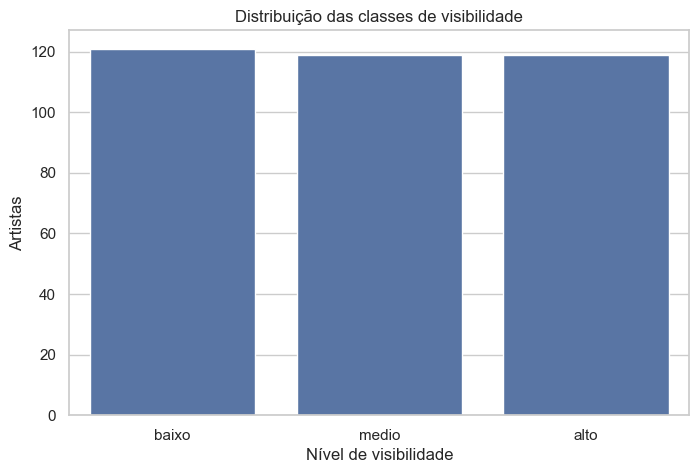

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=base, x=alvo, order=["baixo", "medio", "alto"])
plt.title("Distribuição das classes de visibilidade")
plt.xlabel("Nível de visibilidade")
plt.ylabel("Artistas")
plt.show()


## 2. Treino, teste e modelos

O conjunto de teste representa 25% dos registros e preserva a proporção das classes. Um classificador ingênuo serve como referência; o modelo principal é uma regressão logística multiclasse, simples e interpretável.


In [4]:
X = base[features]
y = base[alvo]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocessamento = ColumnTransformer([
    ("num", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("padronizar", StandardScaler()),
    ]), numericas),
    ("cat", Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categoricas),
])

modelo = Pipeline([
    ("preparar", preprocessamento),
    ("classificar", LogisticRegression(max_iter=3000, class_weight="balanced")),
])
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_treino, y_treino)
modelo.fit(X_treino, y_treino)

pred_baseline = baseline.predict(X_teste)
predicao = modelo.predict(X_teste)
probabilidades = modelo.predict_proba(X_teste)

print({
    "treino": len(X_treino),
    "teste": len(X_teste),
    "acurácia_baseline": round(accuracy_score(y_teste, pred_baseline), 3),
    "acurácia_modelo": round(accuracy_score(y_teste, predicao), 3),
})


{'treino': 269, 'teste': 90, 'acurácia_baseline': 0.333, 'acurácia_modelo': 0.589}


## 3. Matriz de confusão e métricas

A matriz revela quais níveis são confundidos. Precisão, recall e F1 macro tratam as três classes com o mesmo peso.


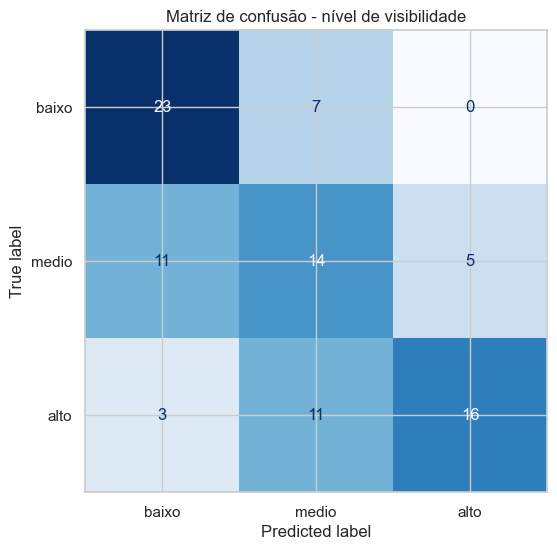

,acurácia,precisão_macro,recall_macro,F1_macro
0,0.589,0.607,0.589,0.589


              precision    recall  f1-score   support

       baixo       0.62      0.77      0.69        30
       medio       0.44      0.47      0.45        30
        alto       0.76      0.53      0.63        30

    accuracy                           0.59        90
   macro avg       0.61      0.59      0.59        90
weighted avg       0.61      0.59      0.59        90



In [5]:
ordem_classes = ["baixo", "medio", "alto"]
matriz = confusion_matrix(y_teste, predicao, labels=ordem_classes)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(matriz, display_labels=ordem_classes).plot(
    ax=ax, cmap="Blues", colorbar=False
)
plt.title("Matriz de confusão - nível de visibilidade")
plt.show()

precisao, recall, f1, _ = precision_recall_fscore_support(
    y_teste, predicao, average="macro", zero_division=0
)
metricas = {
    "acurácia": accuracy_score(y_teste, predicao),
    "precisão_macro": precisao,
    "recall_macro": recall,
    "F1_macro": f1,
}
display(pd.DataFrame([metricas]).round(3))
print(classification_report(y_teste, predicao, labels=ordem_classes, zero_division=0))


## 4. Curvas ROC e Precision-Recall

Como o problema possui três classes, as curvas são calculadas no formato um-contra-todos. A ROC mede separação; a Precision-Recall evidencia o equilíbrio entre precisão e cobertura de cada classe.


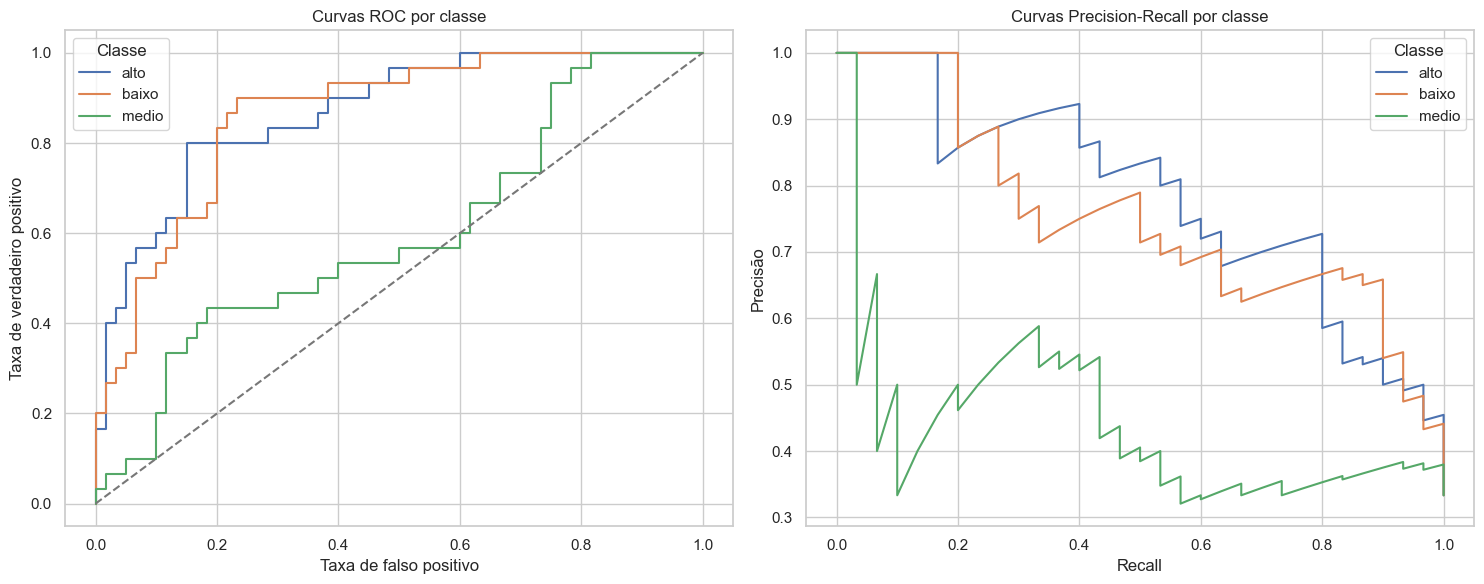

{'ROC_AUC_macro': 0.776, 'Average_Precision_macro': 0.666}


In [6]:
classes_modelo = list(modelo.named_steps["classificar"].classes_)
y_binario = label_binarize(y_teste, classes=classes_modelo)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for indice, classe in enumerate(classes_modelo):
    fpr, tpr, _ = roc_curve(y_binario[:, indice], probabilidades[:, indice])
    precision, recall_curve, _ = precision_recall_curve(
        y_binario[:, indice], probabilidades[:, indice]
    )
    axes[0].plot(fpr, tpr, label=classe)
    axes[1].plot(recall_curve, precision, label=classe)

axes[0].plot([0, 1], [0, 1], "--", color="#777777")
axes[0].set(title="Curvas ROC por classe", xlabel="Taxa de falso positivo", ylabel="Taxa de verdadeiro positivo")
axes[1].set(title="Curvas Precision-Recall por classe", xlabel="Recall", ylabel="Precisão")
for ax in axes:
    ax.legend(title="Classe")
plt.tight_layout()
plt.show()

roc_macro = roc_auc_score(y_binario, probabilidades, average="macro", multi_class="ovr")
pr_macro = average_precision_score(y_binario, probabilidades, average="macro")
print({"ROC_AUC_macro": round(roc_macro, 3), "Average_Precision_macro": round(pr_macro, 3)})


## 5. Importância por permutação

A importância por permutação mede quanto o desempenho cai quando uma feature é embaralhada. Ela ajuda a interpretar o modelo sem afirmar causalidade.


,feature,importância_média,desvio
0,following_count,0.1744,0.0363
1,posts_count,0.0609,0.0206
4,avg_width,0.0400,0.0292
8,is_business,0.0352,0.0190
10,school,0.0312,0.0243
11,region,0.0206,0.0148
9,is_private,0.0073,0.0070
7,possui_website,0.0054,0.0154
6,avg_aspect_ratio,-0.0013,0.0181
12,gender,-0.0127,0.0118


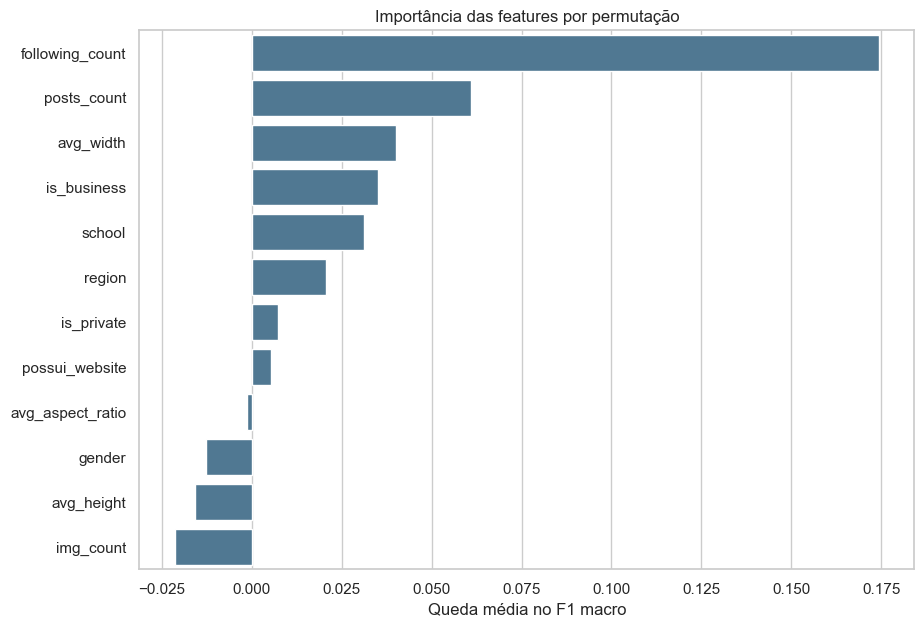

In [7]:
permutacao = permutation_importance(
    modelo, X_teste, y_teste, n_repeats=30, random_state=42, scoring="f1_macro"
)
importancias = (
    pd.DataFrame({
        "feature": features,
        "importância_média": permutacao.importances_mean,
        "desvio": permutacao.importances_std,
    })
    .sort_values("importância_média", ascending=False)
)
display(importancias.round(4))

plt.figure(figsize=(10, 7))
sns.barplot(data=importancias.head(12), x="importância_média", y="feature", color="#457b9d")
plt.title("Importância das features por permutação")
plt.xlabel("Queda média no F1 macro")
plt.ylabel("")
plt.show()


## 6. Exportação do classificador

O pipeline completo, incluindo imputação, padronização e codificação das categorias, é salvo para reprodução.


In [8]:
import joblib

MODELS_DIR = Path("../models/classificacao")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(modelo, MODELS_DIR / "classificador_nivel_visibilidade.joblib")
print(f"Modelo salvo em: {MODELS_DIR / 'classificador_nivel_visibilidade.joblib'}")


Modelo salvo em: ..\models\classificacao\classificador_nivel_visibilidade.joblib


## Conclusões para o FlowCarreiras

1. O modelo testa se sinais disponíveis conseguem distinguir níveis de visibilidade sem usar seguidores diretamente.
2. Desempenho limitado é um resultado importante: popularidade não deve ser tratada como consequência simples do comportamento do artista.
3. O classificador não deve decidir quem merece destaque, oportunidades ou mentoria.
4. No produto, mecanismos de descoberta devem considerar interesses, organização profissional e distribuição justa de exposição.
5. O alvo é derivado de seguidores e o dataset representa artistas ligados a escolas alemãs entre 2018 e 2020; portanto, o modelo não deve ser aplicado diretamente aos usuários do FlowCarreiras.
